In [72]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, accuracy_score, precision_recall_curve
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve, auc
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import seaborn as sn
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt


Initial data shape: (100000, 16)
   year  gender   age location  race:AfricanAmerican  race:Asian  \
0  2020  Female  32.0  Alabama                     0           0   
1  2015  Female  29.0  Alabama                     0           1   
2  2015    Male  18.0  Alabama                     0           0   
3  2015    Male  41.0  Alabama                     0           0   
4  2016  Female  52.0  Alabama                     1           0   

   race:Caucasian  race:Hispanic  race:Other  hypertension  heart_disease  \
0               0              0           1             0              0   
1               0              0           0             0              0   
2               0              0           1             0              0   
3               1              0           0             0              0   
4               0              0           0             0              0   

  smoking_history    bmi  hbA1c_level  blood_glucose_level  diabetes  
0           never  27.32

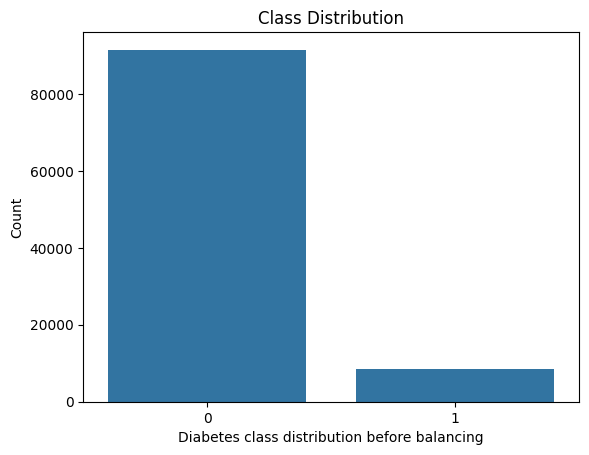

In [73]:
# 1. Load dataset
df = pd.read_csv('diabetes_dataset.csv')
print("Initial data shape:", df.shape)
print(df.head())
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='diabetes')
plt.title('Class Distribution')
plt.xlabel('Diabetes class distribution before balancing')
plt.ylabel('Count')
plt.show()


In [74]:
# 2. Drop unneeded columns
df.drop(columns=[
    'year','location',
    'race:AfricanAmerican','race:Asian','race:Caucasian','race:Hispanic','race:Other',
    'smoking_history'
], inplace=True)
print("After dropping columns:", df.shape)


After dropping columns: (100000, 8)


In [75]:
# 3. Encode gender
encoder = LabelEncoder()
df['gender'] = encoder.fit_transform(df['gender'])
print("Label Encoding Mapping:", dict(zip(encoder.classes_, range(len(encoder.classes_)))))

Label Encoding Mapping: {'Female': 0, 'Male': 1, 'Other': 2}


In [76]:
# 4. Drop duplicates
df.drop_duplicates(inplace=True)
print("After dropping duplicates:", df.shape)

After dropping duplicates: (91313, 8)


After removing 'Other' gender: (91295, 8)


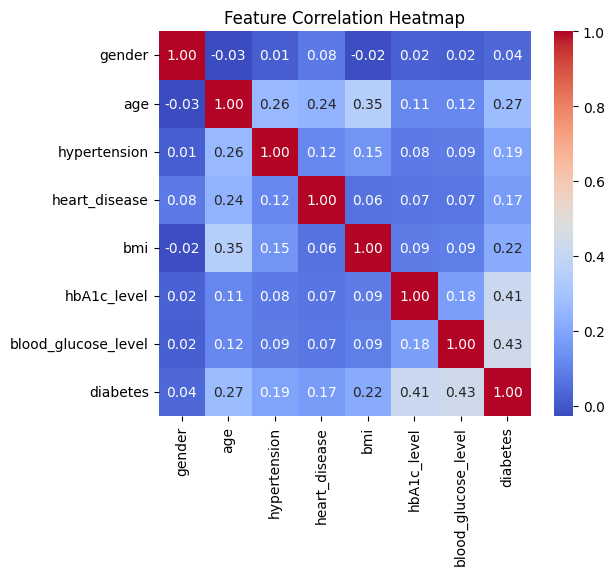

In [77]:
# 5. Remove 'Other' gender (encoded as 2)
df = df[df['gender'] != 2]
print("After removing 'Other' gender:", df.shape)
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(6, 5))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()


After normalization:
            age       bmi  hbA1c_level  blood_glucose_level
99995  0.411912  0.130719     0.545455             0.045455
99996  1.000000  0.311041     0.400000             0.090909
99997  0.574575  0.304739     0.490909             0.354545
99998  0.637137  0.225023     0.454545             0.340909
99999  0.161662  0.083450     0.272727             0.045455


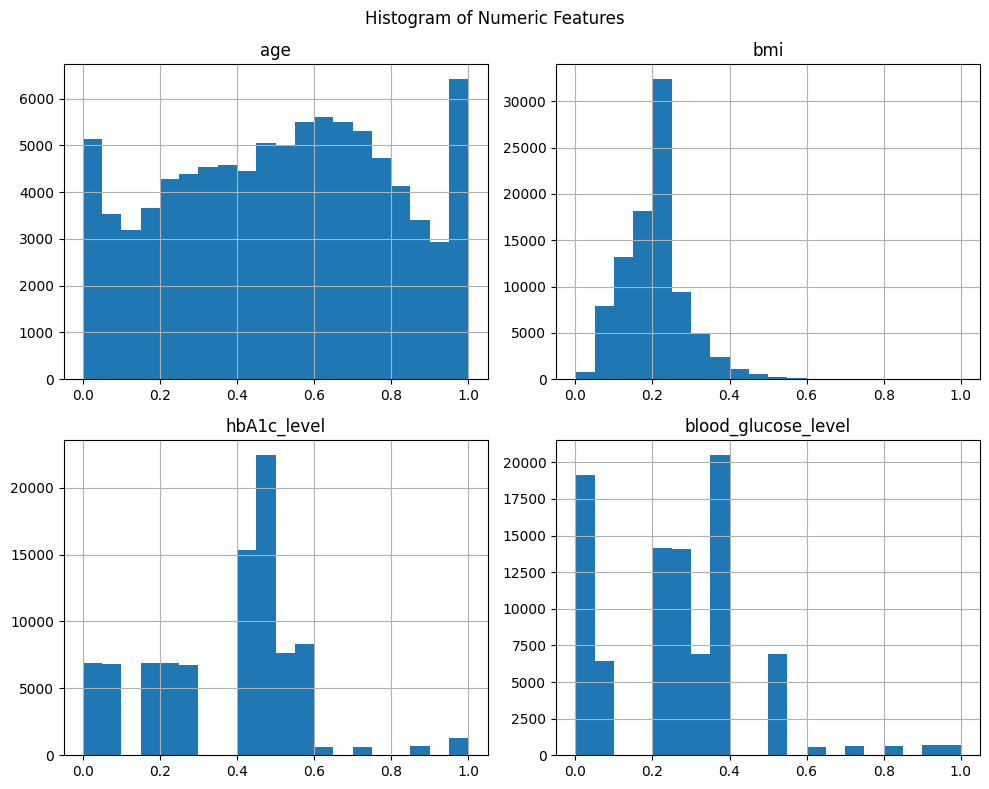

In [78]:
# 6. Normalize numeric columns to [0,1]
cols_to_normalize = ['age','bmi','hbA1c_level','blood_glucose_level']
scaler = MinMaxScaler()
df[cols_to_normalize] = scaler.fit_transform(df[cols_to_normalize])
print("After normalization:")
print(df[cols_to_normalize].tail())
numeric_features = ['age', 'bmi', 'hbA1c_level', 'blood_glucose_level']
df[numeric_features].hist(figsize=(10, 8), bins=20)
plt.suptitle('Histogram of Numeric Features')
plt.tight_layout()
plt.show()





In [79]:
# 7. Prepare features and target
X = df.drop(columns=['diabetes'])
y = df['diabetes']

In [80]:
# 8. Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train/test split:", X_train.shape, X_test.shape)

Train/test split: (73036, 7) (18259, 7)


the gain ratio for gender 0.0012313262620775498
the gain ratio for age 0.010083774513605955
the gain ratio for hypertension 0.04515082704238911
the gain ratio for bmi 0.0077030088729152105
the gain ratio for hbA1c_level 0.05239771635806705
the gain ratio for blood_glucose_level 0.044102518118662566
the gain ratio for heart_disease 0.0519937533740083


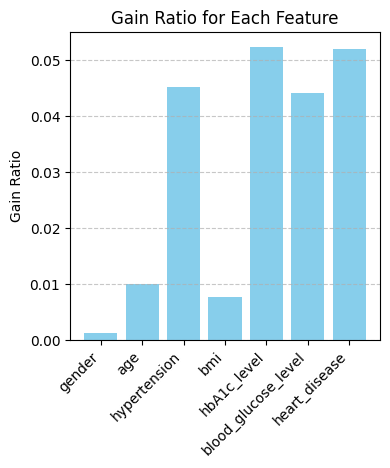

In [81]:

from collections import Counter
import numpy as np

def entropy(labels):
    total_count = len(labels)
    counter = Counter(labels)
    ent = 0.0
    for count in counter.values():
        p = count / total_count
        ent -= p * np.log2(p)
    return ent

def conditional_entropy(X_feature, y_target):
    total_count = len(X_feature)
    feature_values = np.unique(X_feature)
    cond_ent = 0.0
    for value in feature_values:
        subset_y = y_target[X_feature == value]
        p = len(subset_y) / total_count
        cond_ent += p * entropy(subset_y)
    return cond_ent

def information_gain(X_feature, y_target):
    return entropy(y_target) - conditional_entropy(X_feature, y_target)

def split_information(X_feature):
    total_count = len(X_feature)
    feature_values = np.unique(X_feature)
    split_info = 0.0
    for value in feature_values:
        p = np.sum(X_feature == value) / total_count
        split_info -= p * np.log2(p)
    return split_info

def gain_ratio(X_feature, y_target):
    ig = information_gain(X_feature, y_target)
    si = split_information(X_feature)
    if si == 0:
        return 0
    return ig / si


print("the gain ratio for gender", gain_ratio(X_train['gender'], y_train))
print("the gain ratio for age", gain_ratio(X_train['age'], y_train))
print("the gain ratio for hypertension", gain_ratio(X_train['hypertension'], y_train))
print("the gain ratio for bmi", gain_ratio(X_train['bmi'], y_train))
print("the gain ratio for hbA1c_level", gain_ratio(X_train['hbA1c_level'], y_train))
print("the gain ratio for blood_glucose_level", gain_ratio(X_train['blood_glucose_level'], y_train))
print("the gain ratio for heart_disease", gain_ratio(X_train['heart_disease'], y_train))


gain_ratios = {
    'gender': gain_ratio(X_train['gender'], y_train),
    'age': gain_ratio(X_train['age'], y_train),
    'hypertension': gain_ratio(X_train['hypertension'], y_train),
    'bmi': gain_ratio(X_train['bmi'], y_train),
    'hbA1c_level': gain_ratio(X_train['hbA1c_level'], y_train),
    'blood_glucose_level': gain_ratio(X_train['blood_glucose_level'], y_train),
    'heart_disease': gain_ratio(X_train['heart_disease'], y_train)
}


import matplotlib.pyplot as plt

plt.figure(figsize=(4, 4))
plt.bar(gain_ratios.keys(), gain_ratios.values(), color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Gain Ratio')
plt.title('Gain Ratio for Each Feature')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


After SMOTE: (132562, 7)


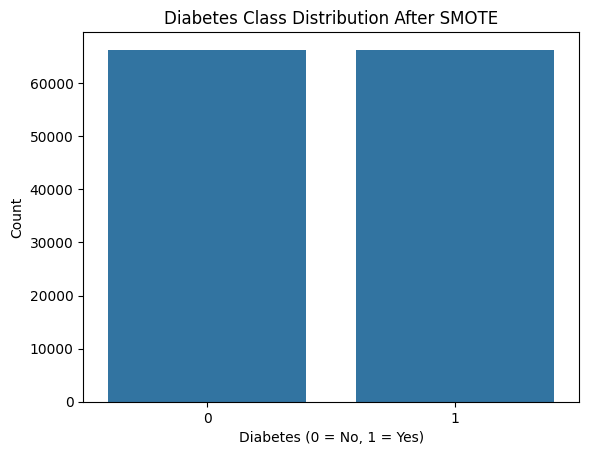

In [82]:
# 9. Balance training set with SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
print("After SMOTE:", X_train_balanced.shape)
sns.countplot(x=y_train_balanced)
plt.title('Diabetes Class Distribution After SMOTE')
plt.xlabel('Diabetes (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()


In [88]:
# 10. Instantiate and train KNN with k=21
knn = KNeighborsClassifier(n_neighbors=21, metric='manhattan', weights='distance')
knn.fit(X_train_balanced, y_train_balanced)

KNeighborsClassifier(metric='manhattan', n_neighbors=21, weights='distance')

In [89]:
# 11. Predict on test set
y_pred = knn.predict(X_test)

In [90]:
# 12. Evaluation metrics
print("\n=== KNN WITHOUT INTERACTIONS (k=21) ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


=== KNN WITHOUT INTERACTIONS (k=21) ===
Accuracy: 0.9105646530478121
Precision: 0.51010101010101
Recall: 0.837181764357608
F1-score: 0.6339385787939924

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.92      0.95     16570
           1       0.51      0.84      0.63      1689

    accuracy                           0.91     18259
   macro avg       0.75      0.88      0.79     18259
weighted avg       0.94      0.91      0.92     18259

Confusion Matrix:
 [[15212  1358]
 [  275  1414]]


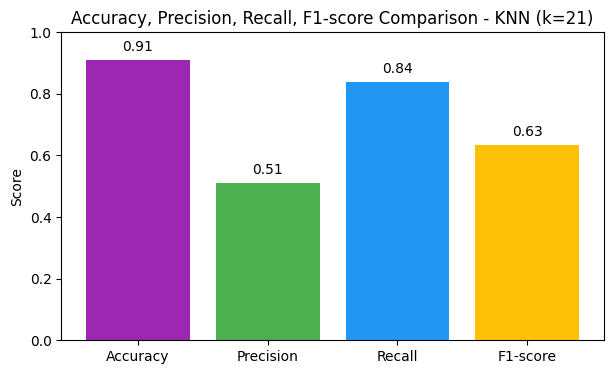

In [91]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
scores = [
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred),
    recall_score(y_test, y_pred),
    f1_score(y_test, y_pred)
]

plt.figure(figsize=(7,4))
bars = plt.bar(metrics, scores, color=['#9C27B0', '#4CAF50', '#2196F3', '#FFC107'])
plt.ylim([0, 1])
plt.title('Accuracy, Precision, Recall, F1-score Comparison - KNN (k=21)')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, round(yval, 2), ha='center', va='bottom')
plt.ylabel('Score')
plt.show()

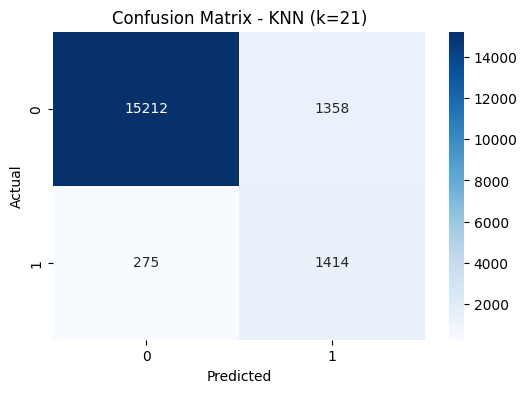

In [92]:


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sn.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - KNN (k=21)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()



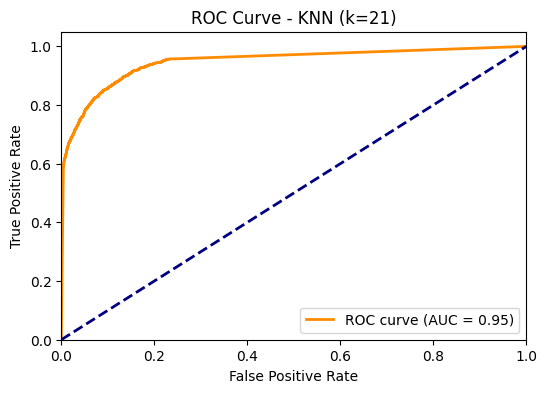

AUC: 0.9468745187451338


In [93]:

y_probs = knn.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - KNN (k=21)')
plt.legend(loc="lower right")
plt.show()

print("AUC:", roc_auc_score(y_test, knn.predict_proba(X_test)[:, 1]))


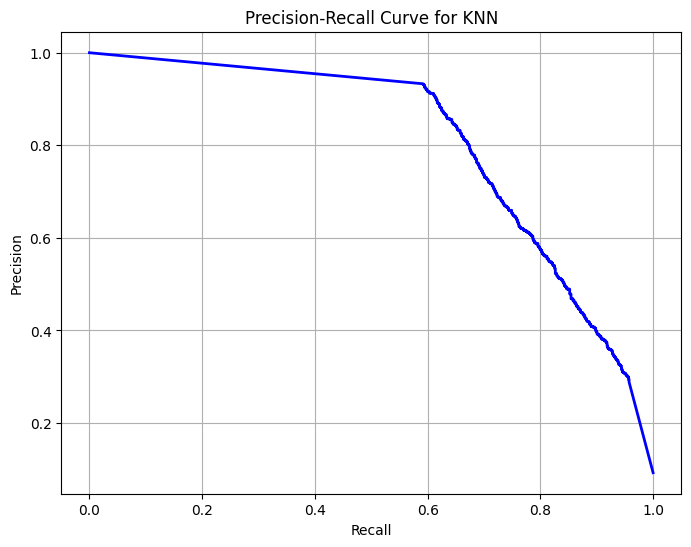

In [94]:
precision_vals, recall_vals, _ = precision_recall_curve(y_test, knn.predict_proba(X_test)[:, 1])
plt.figure(figsize=(8, 6))
plt.plot(recall_vals, precision_vals, color='b', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for KNN')
plt.grid(True)
plt.show()

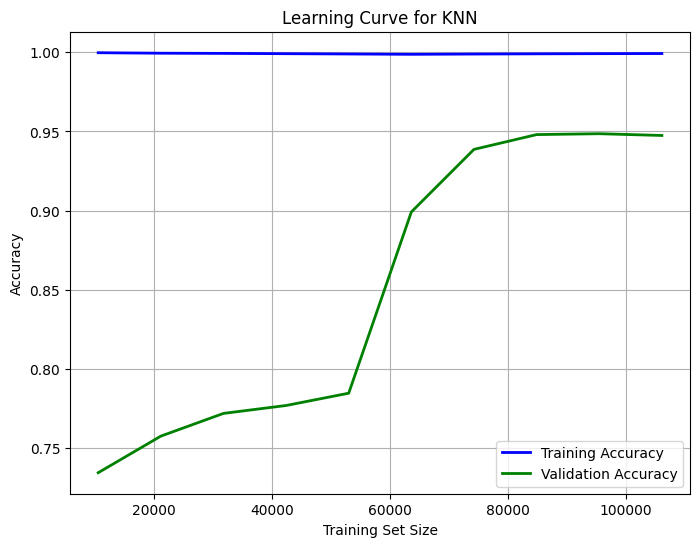

In [95]:
train_sizes, train_scores, valid_scores = learning_curve(
    knn, X_train_balanced, y_train_balanced, cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_scores.mean(axis=1), label='Training Accuracy', color='b', lw=2)
plt.plot(train_sizes, valid_scores.mean(axis=1), label='Validation Accuracy', color='g', lw=2)
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('Learning Curve for KNN')
plt.legend(loc='best')
plt.grid(True)
plt.show()